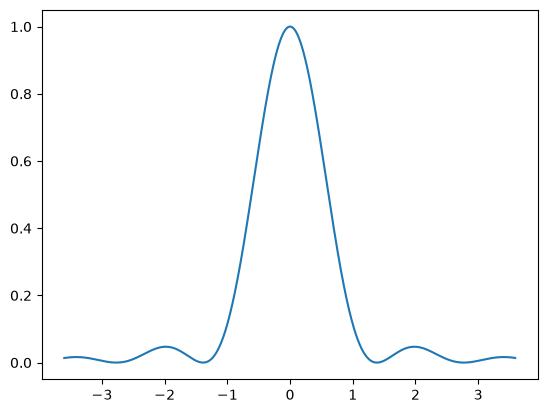

In [2]:
import numpy as np
from scipy.integrate import dblquad
import matplotlib.pyplot as plt


hw_pfs = 0.6

def psf_func(x):
    return np.sinc(x*0.433/hw_pfs)**2

dx = 0.01
num_hw = 6
npts = int(hw_pfs/dx*num_hw*2)

x_plot = np.arange(npts)*dx - hw_pfs*num_hw

plt.figure()

plt.plot(x_plot, psf_func(x_plot))


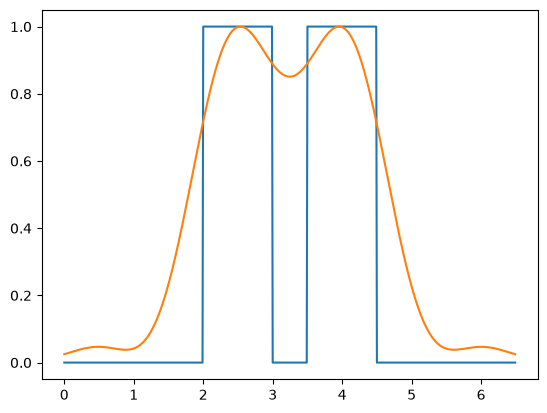

In [ ]:



diameter = 1.0
gap = 0.5

npts = int((6*diameter+gap)/dx)
n_pad = int(2*diameter/dx)


raw_pattern = np.zeros(npts)
raw_pattern[n_pad:n_pad+int(diameter/dx)] = 1.0
raw_pattern[n_pad+int(diameter/dx)+int(gap/dx):n_pad+int(2*diameter/dx)+int(gap/dx)] = 1.0

diffracted_pattern = np.zeros(npts)

for i in range(npts):
    diffracted_pattern[i] = sum([psf_func((i-j)*dx)*raw_pattern[j] for j in range(npts)])

diffracted_pattern /= np.max(diffracted_pattern)


plt.figure()
plt.plot(np.arange(npts)*dx, raw_pattern)
plt.plot(np.arange(npts)*dx, diffracted_pattern)

In [9]:
from scipy.signal import find_peaks

min_dip = 0.265 # based on rayleigh

def find_dip(z, threshold = 0.5):
    peaks, properties = find_peaks(z, height = threshold)
    # print(peaks)
    peak_values = z[peaks]
    peak_positions = z[peaks] 
    # print(peak_values)
    # print(peak_positions[1])

    dip_region = z[peaks[0]:peaks[1]+1]
    local_min_idx = np.argmin(dip_region) + peaks[0]
    local_min_val = z[local_min_idx]
    local_min_z = z[local_min_idx]
    # print("z at true local min:", local_min_z)
    # print("intensity at true local min:", local_min_val)
    contrast_dif = peak_values[0] - local_min_val/peak_values[0]
    # print("contrast dif: ", contrast_dif)
    return local_min_val, local_min_idx, contrast_dif 

diff_pattern_dip_val, diff_pattern_dip_loc, diff_pattern_dip = find_dip(diffracted_pattern)
print(diff_pattern_dip, ", min dip: ", min_dip)

0.14912580098449912 , min dip:  0.265


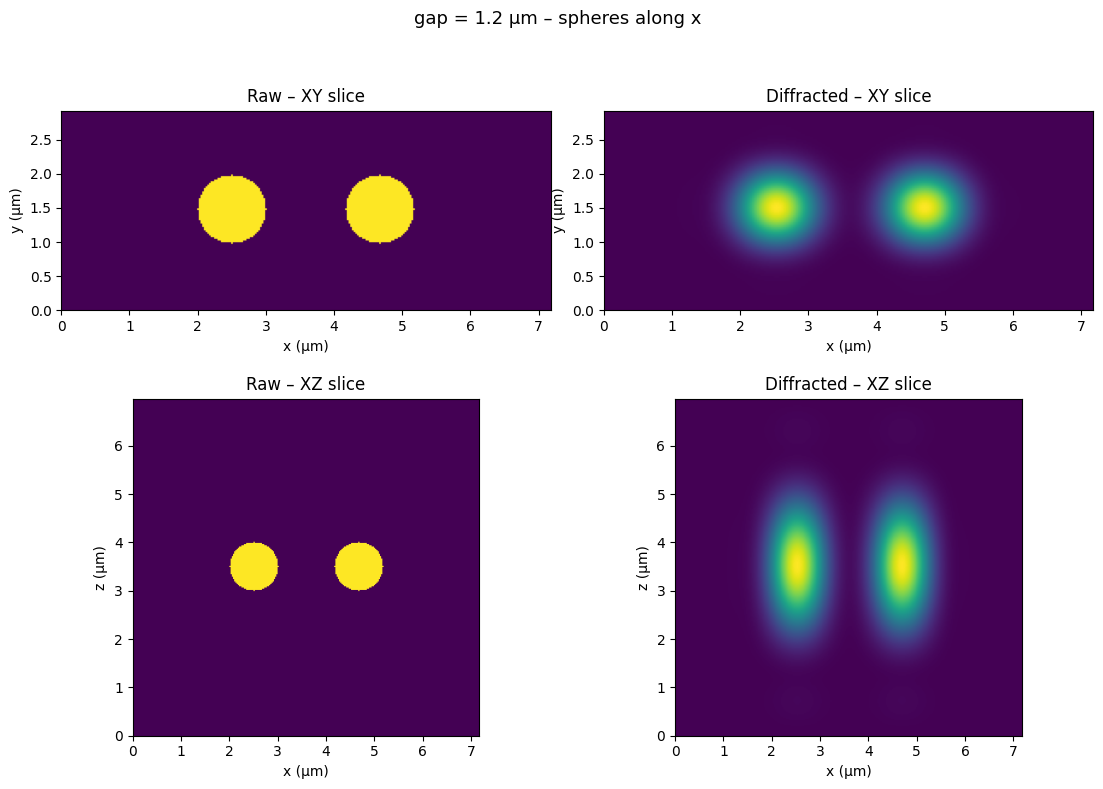

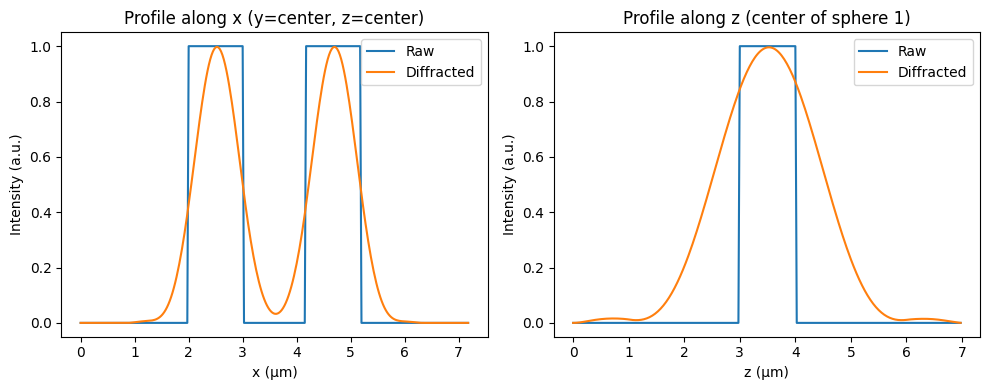

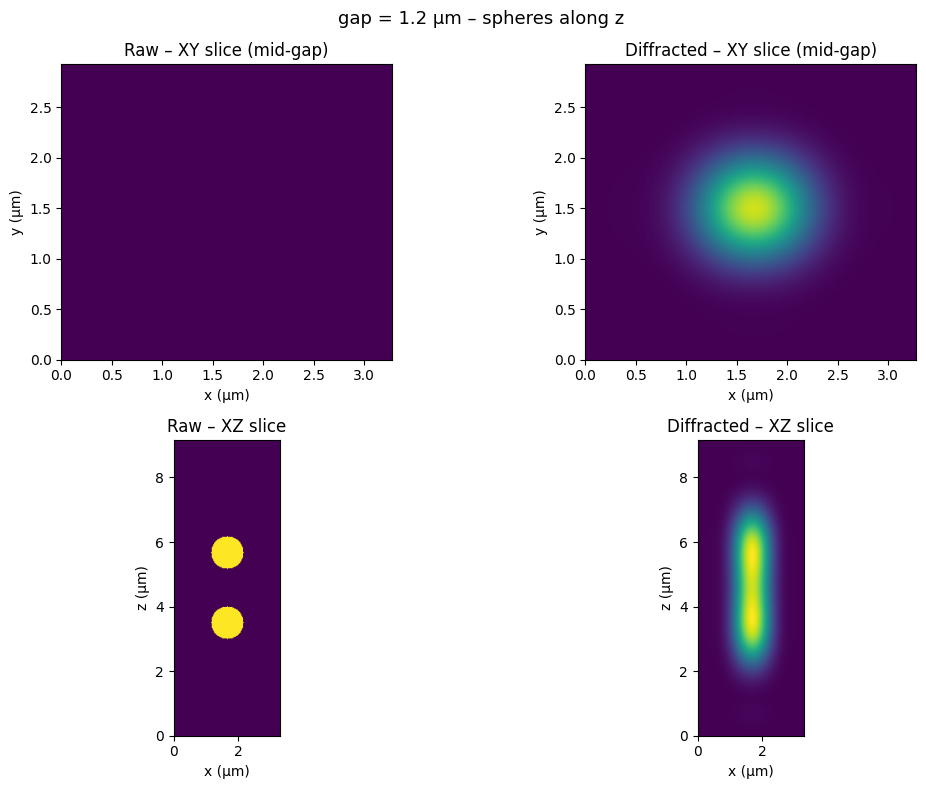

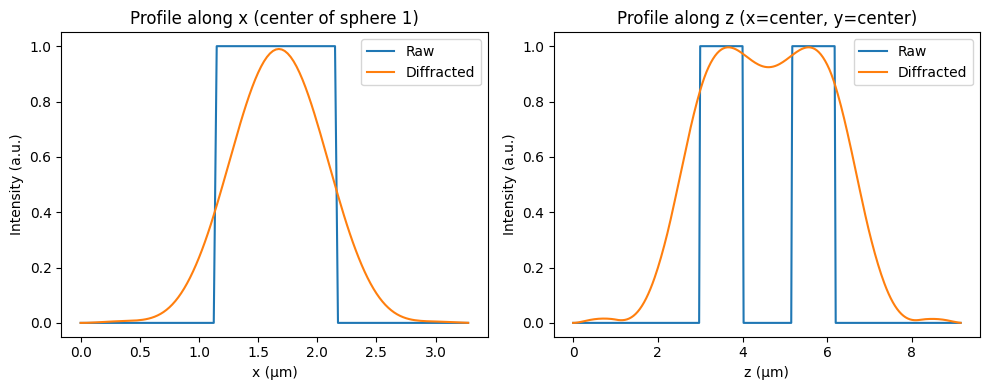

In [61]:
# 3D – spheres along x
from scipy.signal import fftconvolve

hw_x = 0.387
hw_y = 0.3265
hw_z = 1

num_hw = 3
dx = 0.025
diameter = 1
gap = 1.2

npts_x = int((6*diameter + gap) / dx)
npts_y = int((diameter + 2*hw_y*num_hw) / dx)
npts_z = int((diameter + 2*hw_z*num_hw) / dx)
n_pad = int(2*diameter/dx)

ix = np.arange(npts_x)
iy = np.arange(npts_y)
iz = np.arange(npts_z)
X, Y, Z = np.meshgrid(ix, iy, iz, indexing='ij')

cx1 = n_pad + int(0.5*diameter/dx)
cx2 = n_pad + int(1.5*diameter/dx) + int(gap/dx)
cy = npts_y // 2
cz = npts_z // 2

r1 = np.sqrt((X - cx1)**2 + (Y - cy)**2 + (Z - cz)**2) * dx
r2 = np.sqrt((X - cx2)**2 + (Y - cy)**2 + (Z - cz)**2) * dx

raw_pattern_3d = ((r1 <= diameter/2) | (r2 <= diameter/2)).astype(float)

# Anisotropic separable PSF: product of 1D sinc^2 along each axis
def psf_ax(u, hw):
    return np.sinc(u * 0.433 / hw)**2

psf_npts_x = int(hw_x/dx*num_hw*2)
psf_npts_y = int(hw_y/dx*num_hw*2)
psf_npts_z = int(hw_z/dx*num_hw*2)
PX, PY, PZ = np.meshgrid(
    (np.arange(psf_npts_x) - psf_npts_x//2) * dx,
    (np.arange(psf_npts_y) - psf_npts_y//2) * dx,
    (np.arange(psf_npts_z) - psf_npts_z//2) * dx,
    indexing='ij'
)
psf_3d = psf_ax(PX, hw_x) * psf_ax(PY, hw_y) * psf_ax(PZ, hw_z)

diffracted_pattern_3d = fftconvolve(raw_pattern_3d, psf_3d, mode='same')
diffracted_pattern_3d /= diffracted_pattern_3d.max()

x_axis = np.arange(npts_x) * dx
y_axis = np.arange(npts_y) * dx
z_axis = np.arange(npts_z) * dx

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle(f'gap = {gap} µm – spheres along x', fontsize=13)

kw_img = dict(origin='lower', vmin=0, vmax=1)

axes[0, 0].imshow(raw_pattern_3d[:, :, cz].T, aspect='equal',
                  extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]], **kw_img)
axes[0, 0].set_xlabel('x (µm)'); axes[0, 0].set_ylabel('y (µm)')
axes[0, 0].set_title('Raw – XY slice')

axes[0, 1].imshow(diffracted_pattern_3d[:, :, cz].T, aspect='equal',
                  extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]], **kw_img)
axes[0, 1].set_xlabel('x (µm)'); axes[0, 1].set_ylabel('y (µm)')
axes[0, 1].set_title('Diffracted – XY slice')

axes[1, 0].imshow(raw_pattern_3d[:, cy, :].T, aspect='equal',
                  extent=[x_axis[0], x_axis[-1], z_axis[0], z_axis[-1]], **kw_img)
axes[1, 0].set_xlabel('x (µm)'); axes[1, 0].set_ylabel('z (µm)')
axes[1, 0].set_title('Raw – XZ slice')

axes[1, 1].imshow(diffracted_pattern_3d[:, cy, :].T, aspect='equal',
                  extent=[x_axis[0], x_axis[-1], z_axis[0], z_axis[-1]], **kw_img)
axes[1, 1].set_xlabel('x (µm)'); axes[1, 1].set_ylabel('z (µm)')
axes[1, 1].set_title('Diffracted – XZ slice')

plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x_axis, raw_pattern_3d[:, cy, cz], label='Raw')
axes[0].plot(x_axis, diffracted_pattern_3d[:, cy, cz], label='Diffracted')
axes[0].set_xlabel('x (µm)'); axes[0].set_ylabel('Intensity (a.u.)')
axes[0].set_title('Profile along x (y=center, z=center)')
axes[0].legend()

axes[1].plot(z_axis, raw_pattern_3d[cx1, cy, :], label='Raw')
axes[1].plot(z_axis, diffracted_pattern_3d[cx1, cy, :], label='Diffracted')
axes[1].set_xlabel('z (µm)'); axes[1].set_ylabel('Intensity (a.u.)')
axes[1].set_title('Profile along z (center of sphere 1)')
axes[1].legend()

plt.tight_layout()

# 3D – spheres along z (same gap)
npts_x_z = int((diameter + 2*hw_x*num_hw) / dx)
npts_y_z = int((diameter + 2*hw_y*num_hw) / dx)
npts_z_z = int((2*diameter + gap + 2*hw_z*num_hw) / dx)

cx_z = npts_x_z // 2
cy_z = npts_y_z // 2
cz1_z = int(hw_z*num_hw/dx) + int(0.5*diameter/dx)
cz2_z = cz1_z + int(diameter/dx) + int(gap/dx)

X_z, Y_z, Z_z = np.meshgrid(np.arange(npts_x_z), np.arange(npts_y_z), np.arange(npts_z_z), indexing='ij')

r1_z = np.sqrt((X_z - cx_z)**2 + (Y_z - cy_z)**2 + (Z_z - cz1_z)**2) * dx
r2_z = np.sqrt((X_z - cx_z)**2 + (Y_z - cy_z)**2 + (Z_z - cz2_z)**2) * dx

raw_z = ((r1_z <= diameter/2) | (r2_z <= diameter/2)).astype(float)

diffracted_z = fftconvolve(raw_z, psf_3d, mode='same')
diffracted_z /= diffracted_z.max()

x_axis_z = np.arange(npts_x_z) * dx
y_axis_z = np.arange(npts_y_z) * dx
z_axis_z = np.arange(npts_z_z) * dx

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle(f'gap = {gap} µm – spheres along z', fontsize=13)

axes[0, 0].imshow(raw_z[:, :, (cz1_z+cz2_z)//2].T, aspect='equal',
                  extent=[x_axis_z[0], x_axis_z[-1], y_axis_z[0], y_axis_z[-1]], **kw_img)
axes[0, 0].set_xlabel('x (µm)'); axes[0, 0].set_ylabel('y (µm)')
axes[0, 0].set_title('Raw – XY slice (mid-gap)')

axes[0, 1].imshow(diffracted_z[:, :, (cz1_z+cz2_z)//2].T, aspect='equal',
                  extent=[x_axis_z[0], x_axis_z[-1], y_axis_z[0], y_axis_z[-1]], **kw_img)
axes[0, 1].set_xlabel('x (µm)'); axes[0, 1].set_ylabel('y (µm)')
axes[0, 1].set_title('Diffracted – XY slice (mid-gap)')

axes[1, 0].imshow(raw_z[:, cy_z, :].T, aspect='equal',
                  extent=[x_axis_z[0], x_axis_z[-1], z_axis_z[0], z_axis_z[-1]], **kw_img)
axes[1, 0].set_xlabel('x (µm)'); axes[1, 0].set_ylabel('z (µm)')
axes[1, 0].set_title('Raw – XZ slice')

axes[1, 1].imshow(diffracted_z[:, cy_z, :].T, aspect='equal',
                  extent=[x_axis_z[0], x_axis_z[-1], z_axis_z[0], z_axis_z[-1]], **kw_img)
axes[1, 1].set_xlabel('x (µm)'); axes[1, 1].set_ylabel('z (µm)')
axes[1, 1].set_title('Diffracted – XZ slice')

plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x_axis_z, raw_z[:, cy_z, cz1_z], label='Raw')
axes[0].plot(x_axis_z, diffracted_z[:, cy_z, cz1_z], label='Diffracted')
axes[0].set_xlabel('x (µm)'); axes[0].set_ylabel('Intensity (a.u.)')
axes[0].set_title('Profile along x (center of sphere 1)')
axes[0].legend()

axes[1].plot(z_axis_z, raw_z[cx_z, cy_z, :], label='Raw')
axes[1].plot(z_axis_z, diffracted_z[cx_z, cy_z, :], label='Diffracted')
axes[1].set_xlabel('z (µm)'); axes[1].set_ylabel('Intensity (a.u.)')
axes[1].set_title('Profile along z (x=center, y=center)')
axes[1].legend()

plt.tight_layout()



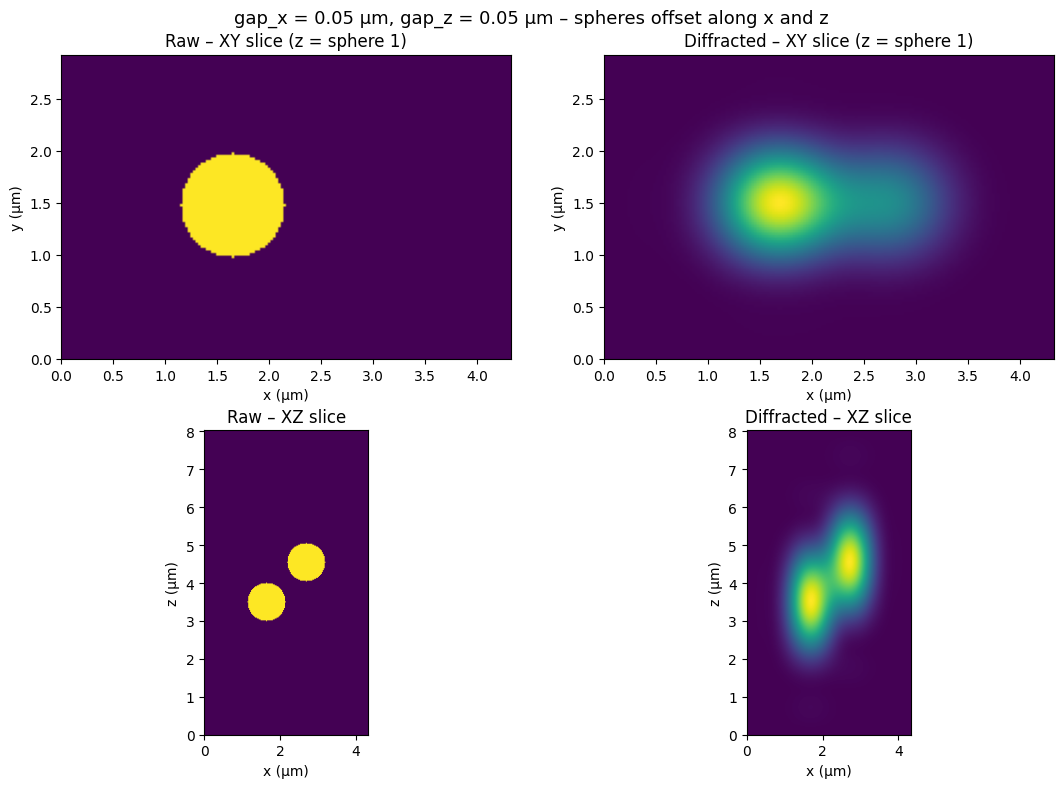

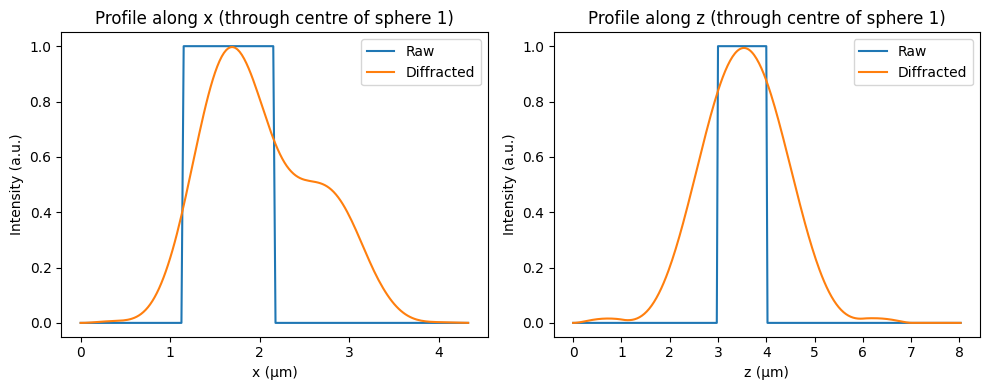

In [68]:
# 3D – spheres offset along both x and z
gap_x = 0.05
gap_z = 0.05

npts_x_xz = int((2*diameter + gap_x + 2*hw_x*num_hw) / dx)
npts_y_xz = int((diameter + 2*hw_y*num_hw) / dx)
npts_z_xz = int((2*diameter + gap_z + 2*hw_z*num_hw) / dx)

cy_xz = npts_y_xz // 2
cx1_xz = int(hw_x*num_hw/dx) + int(0.5*diameter/dx)
cx2_xz = cx1_xz + int(diameter/dx) + int(gap_x/dx)
cz1_xz = int(hw_z*num_hw/dx) + int(0.5*diameter/dx)
cz2_xz = cz1_xz + int(diameter/dx) + int(gap_z/dx)

X_xz, Y_xz, Z_xz = np.meshgrid(
    np.arange(npts_x_xz), np.arange(npts_y_xz), np.arange(npts_z_xz), indexing='ij'
)

r1_xz = np.sqrt((X_xz - cx1_xz)**2 + (Y_xz - cy_xz)**2 + (Z_xz - cz1_xz)**2) * dx
r2_xz = np.sqrt((X_xz - cx2_xz)**2 + (Y_xz - cy_xz)**2 + (Z_xz - cz2_xz)**2) * dx

raw_xz = ((r1_xz <= diameter/2) | (r2_xz <= diameter/2)).astype(float)

diffracted_xz = fftconvolve(raw_xz, psf_3d, mode='same')
diffracted_xz /= diffracted_xz.max()

x_axis_xz = np.arange(npts_x_xz) * dx
y_axis_xz = np.arange(npts_y_xz) * dx
z_axis_xz = np.arange(npts_z_xz) * dx

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle(f'gap_x = {gap_x} µm, gap_z = {gap_z} µm – spheres offset along x and z', fontsize=13)

axes[0, 0].imshow(raw_xz[:, :, cz1_xz].T, aspect='equal',
                  extent=[x_axis_xz[0], x_axis_xz[-1], y_axis_xz[0], y_axis_xz[-1]], **kw_img)
axes[0, 0].set_xlabel('x (µm)'); axes[0, 0].set_ylabel('y (µm)')
axes[0, 0].set_title('Raw – XY slice (z = sphere 1)')

axes[0, 1].imshow(diffracted_xz[:, :, cz1_xz].T, aspect='equal',
                  extent=[x_axis_xz[0], x_axis_xz[-1], y_axis_xz[0], y_axis_xz[-1]], **kw_img)
axes[0, 1].set_xlabel('x (µm)'); axes[0, 1].set_ylabel('y (µm)')
axes[0, 1].set_title('Diffracted – XY slice (z = sphere 1)')

axes[1, 0].imshow(raw_xz[:, cy_xz, :].T, aspect='equal',
                  extent=[x_axis_xz[0], x_axis_xz[-1], z_axis_xz[0], z_axis_xz[-1]], **kw_img)
axes[1, 0].set_xlabel('x (µm)'); axes[1, 0].set_ylabel('z (µm)')
axes[1, 0].set_title('Raw – XZ slice')

axes[1, 1].imshow(diffracted_xz[:, cy_xz, :].T, aspect='equal',
                  extent=[x_axis_xz[0], x_axis_xz[-1], z_axis_xz[0], z_axis_xz[-1]], **kw_img)
axes[1, 1].set_xlabel('x (µm)'); axes[1, 1].set_ylabel('z (µm)')
axes[1, 1].set_title('Diffracted – XZ slice')

plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x_axis_xz, raw_xz[:, cy_xz, cz1_xz], label='Raw')
axes[0].plot(x_axis_xz, diffracted_xz[:, cy_xz, cz1_xz], label='Diffracted')
axes[0].set_xlabel('x (µm)'); axes[0].set_ylabel('Intensity (a.u.)')
axes[0].set_title('Profile along x (through centre of sphere 1)')
axes[0].legend()

axes[1].plot(z_axis_xz, raw_xz[cx1_xz, cy_xz, :], label='Raw')
axes[1].plot(z_axis_xz, diffracted_xz[cx1_xz, cy_xz, :], label='Diffracted')
axes[1].set_xlabel('z (µm)'); axes[1].set_ylabel('Intensity (a.u.)')
axes[1].set_title('Profile along z (through centre of sphere 1)')
axes[1].legend()

plt.tight_layout()
